In [ ]:
import torch
import torch.nn as nn

#Creating MLP with 3 layers
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 1)
)


In [ ]:
# Creating Datapoints and target function
x = -torch.pi + 2*torch.pi*torch.rand(100,1).reshape(-1,1) #taking random points between -pi to pi
y = torch.sin(x)

In [ ]:
# Defining Loss Function and Choosing Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training the model to learn the target Function
for epoch in range(5000):
    pred = model(x)

    loss = criterion(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
# Testing the model
test = torch.tensor([[1.57/3]]) # pi/3
print(model(test))

tensor([[0.4996]], grad_fn=<AddmmBackward0>)


In [ ]:

x.requires_grad_(True) # to track the gradients
u = model(x)

# du/dx
u_x = torch.autograd.grad(
    u,
    x,
    grad_outputs=torch.ones_like(u),
    create_graph=True
)[0]

#du2/dx2
u_xx = torch.autograd.grad(u_x,x,grad_outputs=torch.ones_like(u_x))[0]

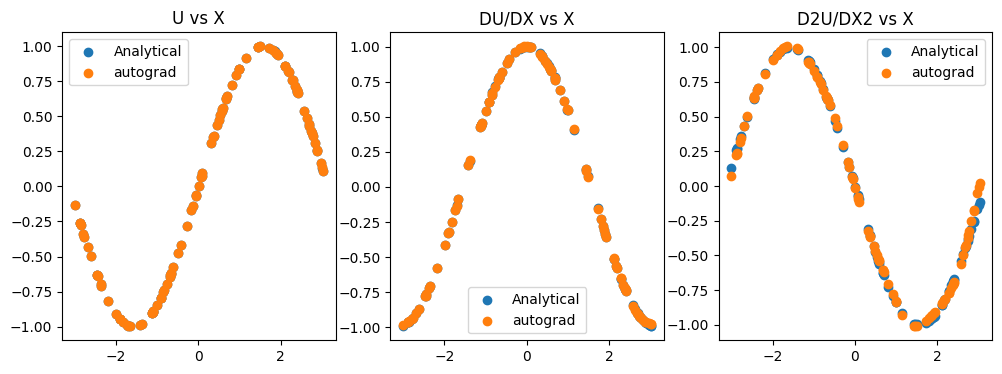

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
y_=torch.sin(x)
plt.title('U vs X')
plt.subplot(1,3,1)
plt.scatter(x.detach().cpu().numpy(),y_.detach().cpu().numpy(),label='Analytical')# cant directly paas tensors which are being tracked(.requires_grad==true)
plt.scatter(x.detach().cpu().numpy(),u.detach().cpu().numpy(),label='autograd')
plt.legend()

plt.subplot(1,3,2)
y_=torch.cos(x)
plt.title('DU/DX vs X')
plt.scatter(x.detach().cpu().numpy(),y_.detach().cpu().numpy(),label='Analytical')
plt.scatter(x.detach().cpu().numpy(),u_x.detach().cpu().numpy(),label='autograd')
plt.legend()

plt.subplot(1,3,3)
y_=-torch.sin(x)
plt.title('D2U/DX2 vs X')
plt.scatter(x.detach().cpu().numpy(),y_.detach().cpu().numpy(),label='Analytical')
plt.scatter(x.detach().cpu().numpy(),u_xx.detach().cpu().numpy(),label='autograd')
plt.legend()